# FIFA World Cup Analysis 1930-2026

Analysis of every FIFA World Cup from Uruguay 1930 through the 48-team 2026 edition.

| Era | Data |
|---|---|
| 1930-2014 | 836 historical match results (20 tournaments) |
| 2018 | Russia: match stats, every goal, team rankings |
| 2022 | Qatar: rich match-by-match team stats |
| 2026 | Full schedule **with simulated results** (scores, penalties, xG, POTM) |

> The 2026 dataset is a simulation - all 104 matches are marked `Completed`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
DATA = Path('.')  # notebook lives in the repo root

## 1. Load & Clean

In [2]:
def clean_team(name):
    """Strip HTML artifacts ('rn">') and stray quotes from team names."""
    if pd.isna(name):
        return None
    s = str(name).replace('rn">', '').replace('"', '')
    return ' '.join(s.split())

# --- Historical 1930-2014 ---
hist = pd.read_csv(DATA / 'WC_1930-2014.csv')
n_raw = len(hist)
hist = hist.dropna(subset=['Year']).drop_duplicates()   # drop blank rows + exact duplicates
hist['Year'] = hist['Year'].astype(int)
hist['Attendance'] = pd.to_numeric(hist['Attendance'], errors='coerce')
for col in ('Home Team Name', 'Away Team Name'):
    hist[col] = hist[col].map(clean_team)
for col in ('Home Team Goals', 'Away Team Goals'):
    hist[col] = pd.to_numeric(hist[col], errors='coerce').fillna(0).astype(int)
hist['total_goals'] = hist['Home Team Goals'] + hist['Away Team Goals']
assert hist['MatchID'].is_unique and len(hist) == 836
print(f'Historical: {len(hist)} matches ({n_raw} raw rows), {hist["Year"].nunique()} tournaments')

# --- 2018 ---
m18 = pd.read_csv(DATA / 'World_cup_2018_matches.csv')
g18 = pd.read_csv(DATA / 'World_cup_2018_goals.csv')
c18 = pd.read_csv(DATA / 'World_cup_2018_country.csv')
m18['total_goals'] = m18['Home_goals'] + m18['Away_goals']
print(f'2018: {len(m18)} matches, {len(g18)} goals, {len(c18)} teams')

# --- 2022 (possession arrives as "42%" strings -> strip % defensively) ---
d22 = pd.read_csv(DATA / 'WC_2022.csv')
pct_cols = [c for c in d22.columns if d22[c].astype(str).str.contains('%').any()]
for c in pct_cols:
    d22[c] = pd.to_numeric(d22[c].astype(str).str.replace('%', '', regex=False), errors='coerce')
id_like = ('team1', 'team2', 'date', 'hour', 'category', 'team', 'Group')
for c in d22.columns:
    if c not in id_like:
        d22[c] = pd.to_numeric(d22[c], errors='coerce')
assert d22['possession team1'].between(0, 100).all()
print(f'2022: {len(d22)} matches, % stripped from {len(pct_cols)} cols')

# --- 2026 (simulated) ---
teams26 = pd.read_csv(DATA / 'teams.csv')
matches26 = pd.read_csv(DATA / 'matches.csv')
venues26 = pd.read_csv(DATA / 'venues.csv')
stages26 = pd.read_csv(DATA / 'tournament_stages.csv')
players26 = pd.read_csv(DATA / 'player_stats.csv')
referees26 = pd.read_csv(DATA / 'referees.csv')
print(f'2026: {len(matches26)} matches, {len(teams26)} teams, {len(venues26)} venues, status={matches26["status"].unique()}')

Historical: 836 matches (836 raw rows), 20 tournaments
2018: 64 matches, 169 goals, 32 teams
2022: 64 matches, % stripped from 0 cols
2026: 104 matches, 48 teams, 16 venues, status=<StringArray>
['Completed']
Length: 1, dtype: str


## 2. Historical Trends (1930-2014)

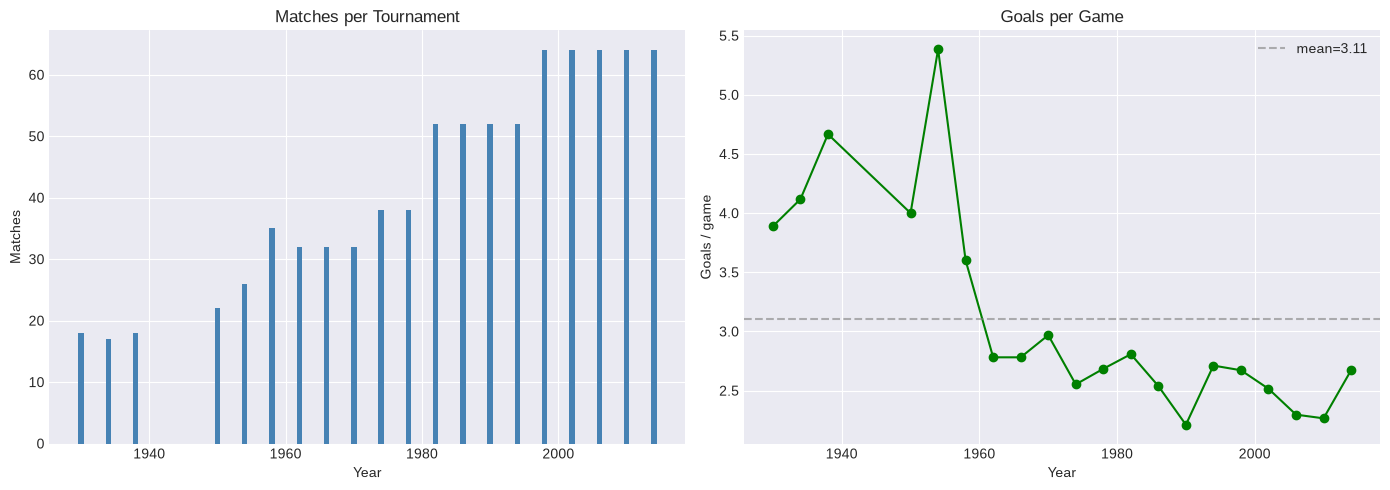

In [3]:
yearly = hist.groupby('Year').agg(
    matches=('MatchID', 'count'),
    goals=('total_goals', 'sum'),
    gpg=('total_goals', 'mean'),
    avg_att=('Attendance', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(yearly['Year'], yearly['matches'], color='steelblue')
axes[0].set_title('Matches per Tournament')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Matches')
axes[1].plot(yearly['Year'], yearly['gpg'], 'o-', color='green')
axes[1].axhline(yearly['gpg'].mean(), ls='--', color='gray', alpha=.6, label=f"mean={yearly['gpg'].mean():.2f}")
axes[1].set_title('Goals per Game')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Goals / game'); axes[1].legend()
plt.tight_layout(); plt.show()

/tmp/ipykernel_129973/85647013.py:18: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()


/home/qdot/Projects/World-Cup-1930-2026/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


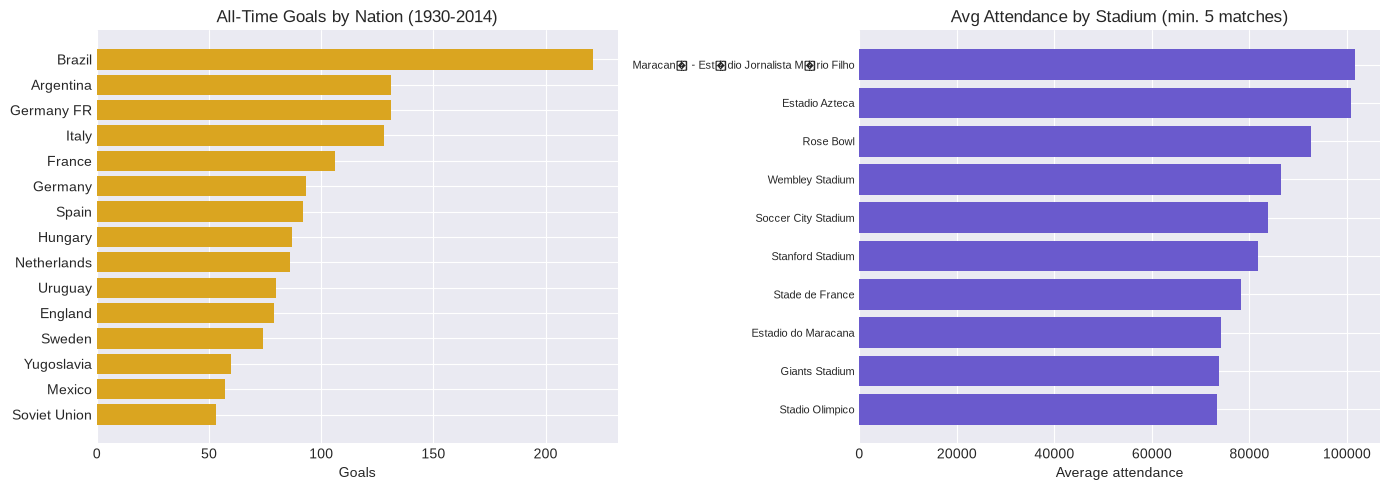

In [4]:
# All-time scorers (per nation) and biggest stages
goals_h = hist[['Home Team Name', 'Home Team Goals']].rename(columns={'Home Team Name':'team','Home Team Goals':'g'})
goals_a = hist[['Away Team Name', 'Away Team Goals']].rename(columns={'Away Team Name':'team','Away Team Goals':'g'})
top_nations = pd.concat([goals_h, goals_a]).groupby('team')['g'].sum().nlargest(15)

top_stadia = (hist.groupby('Stadium')['Attendance'].agg(['mean','count'])
              .query('count >= 5').nlargest(10, 'mean'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_nations.index[::-1], top_nations.values[::-1], color='goldenrod')
axes[0].set_title('All-Time Goals by Nation (1930-2014)')
axes[0].set_xlabel('Goals')
axes[1].barh(range(len(top_stadia)), top_stadia['mean'].values, color='slateblue')
axes[1].set_yticks(range(len(top_stadia)), top_stadia.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('Avg Attendance by Stadium (min. 5 matches)')
axes[1].set_xlabel('Average attendance')
plt.tight_layout(); plt.show()

In [5]:
# Who won what? Champion = whichever finalist appears in 'Win conditions'
finals = hist[hist['Stage'] == 'Final'].copy()
def champion(r):
    wc = str(r['Win conditions']) if pd.notna(r['Win conditions']) else ''
    if r['Home Team Name'] in wc: return r['Home Team Name']
    if r['Away Team Name'] in wc: return r['Away Team Name']
    if r['Home Team Goals'] > r['Away Team Goals']: return r['Home Team Name']
    if r['Away Team Goals'] > r['Home Team Goals']: return r['Away Team Name']
    return None

finals['champion'] = finals.apply(champion, axis=1)
titles = finals['champion'].value_counts()
print(f'{len(finals)} finals (1950 had none - final group round)\n')
display(titles.to_frame('titles'))

19 finals (1950 had none - final group round)



,titles
champion,
Brazil,5
Italy,4
Germany FR,3
Argentina,2
Uruguay,1
England,1
France,1
Spain,1
Germany,1


## 3. Russia 2018

In [6]:
# Shootout-aware results: Penalties=='Y' -> PK score decides, not the 1-1 scoreline
def row_outcome(r):
    if r['Penalties'] == 'Y':
        return 'H' if r['Home_PK_made'] > r['Away_PK_made'] else 'A'
    if r['Home_goals'] != r['Away_goals']: return 'H' if r['Home_goals'] > r['Away_goals'] else 'A'
    return 'D'

m18['outcome'] = m18.apply(row_outcome, axis=1)
print('Shootouts:', m18.loc[m18['Penalties']=='Y', ['Home','Away','Home_goals','Away_goals','Home_PK_made','Away_PK_made']].to_string(index=False))

Shootouts:     Home    Away  Home_goals  Away_goals  Home_PK_made  Away_PK_made
   Spain  Russia           1           1           3.0           4.0
 Croatia Denmark           1           1           3.0           2.0
Colombia England           1           1           3.0           4.0
  Russia Croatia           2           2           3.0           4.0


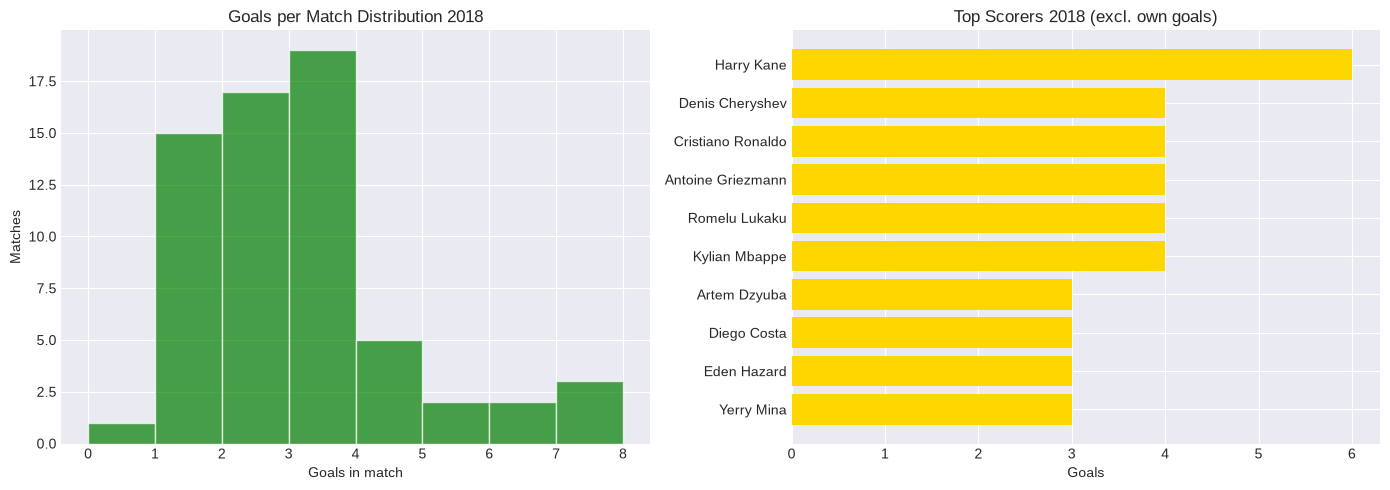

In [7]:
# Goal timing + top scorers (own goals excluded)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(m18['total_goals'], bins=range(0, 9), color='green', alpha=.7, edgecolor='white')
axes[0].set_title('Goals per Match Distribution 2018')
axes[0].set_xlabel('Goals in match'); axes[0].set_ylabel('Matches')

scorers = g18.loc[g18['Own_goal'] == 'N', 'Player_scored'].value_counts().head(10)
axes[1].barh(scorers.index[::-1], scorers.values[::-1], color='gold')
axes[1].set_title('Top Scorers 2018 (excl. own goals)')
axes[1].set_xlabel('Goals')
plt.tight_layout(); plt.show()

In [8]:
# Final 2018 table (shootout wins = 3 pts)
perf = {}
for _, r in m18.iterrows():
    h, a = clean_team(r['Home']), clean_team(r['Away'])
    for t, gf, ga, o in ((h, r['Home_goals'], r['Away_goals'], r['outcome']), (a, r['Away_goals'], r['Home_goals'], {'H':'A','A':'H','D':'D'}[r['outcome']])):
        p = perf.setdefault(t, {'P':0,'W':0,'D':0,'L':0,'GF':0,'GA':0,'Pts':0,'poss':[]})
        p['P'] += 1; p['GF'] += gf; p['GA'] += ga
        p['poss'].append(r['Home_possession'] if t == h else r['Away_possession'])
        if o == 'H': p['W'] += 1; p['Pts'] += 3
        elif o == 'D': p['D'] += 1; p['Pts'] += 1
        else: p['L'] += 1
table18 = (pd.DataFrame(perf).T.assign(GD=lambda d: d['GF'] - d['GA'],
              Poss=lambda d: d['poss'].apply(lambda v: round(np.mean(v), 1)))
           .drop(columns='poss').sort_values(['Pts','GD'], ascending=False))
table18.index.name = 'Team'
display(table18)

,P,W,D,L,GF,GA,Pts,GD,Poss
Team,,,,,,,,,
Croatia,7,7,0,0,16,7,21,9,52.6
Belgium,7,6,0,1,16,6,18,10,52.9
France,7,5,1,1,12,8,16,4,52.7
Uruguay,5,4,0,1,7,3,12,4,47.0
England,7,4,0,3,12,8,12,4,54.3
Brazil,5,3,1,1,8,3,10,5,58.6
Russia,5,3,0,2,11,7,9,4,37.0
Sweden,5,3,0,2,6,4,9,2,37.4
Colombia,4,2,0,2,6,3,6,3,50.0


## 4. Qatar 2022

In [9]:
# Per-team aggregates (possession cleaned above)
def side_df(df, n):
    """One row per match for team n (1 or 2); opponent goals as ga."""
    return pd.DataFrame({
        'team': df[f'team{n}'],
        'gf': df[f'number of goals team{n}'], 'ga': df[f'number of goals team{3-n}'],
        'poss': df[f'possession team{n}'], 'shots': df[f'total attempts team{n}'],
        'ont': df[f'on target attempts team{n}'], 'pass': df[f'passes completed team{n}'],
        'fouls': df[f'fouls against team{n}'], 'yellow': df[f'yellow cards team{n}'],
    })

perf22 = (pd.concat([side_df(d22, 1), side_df(d22, 2)]).groupby('team').agg(
            GF=('gf', 'sum'), GA=('ga', 'sum'), Poss=('poss', 'mean'),
            Shots=('shots', 'sum'), OnTarget=('ont', 'sum'), Passes=('pass', 'sum'),
            Fouls=('fouls', 'sum'), Yellows=('yellow', 'sum'))
          .assign(GD=lambda d: d.GF - d.GA)
          .sort_values(['GD', 'GF'], ascending=False))
assert perf22['Poss'].min() > 0 and perf22.loc['FRANCE', 'GF'] == 16
display(perf22.head(8))

,GF,GA,Poss,Shots,OnTarget,Passes,Fouls,Yellows,GD
team,,,,,,,,,
ENGLAND,13,4,57.800000,60,27,2723,53,1,9
FRANCE,16,8,44.857143,101,35,3192,69,8,8
ARGENTINA,15,8,51.142857,104,48,3841,100,16,7
PORTUGAL,12,6,54.200000,62,25,2615,56,6,6
NETHERLANDS,10,4,45.000000,40,16,2442,87,12,6
SPAIN,9,3,69.000000,51,16,3527,41,2,6
BRAZIL,8,3,50.400000,90,41,2696,63,6,5
CROATIA,8,7,48.000000,81,28,3724,90,8,1


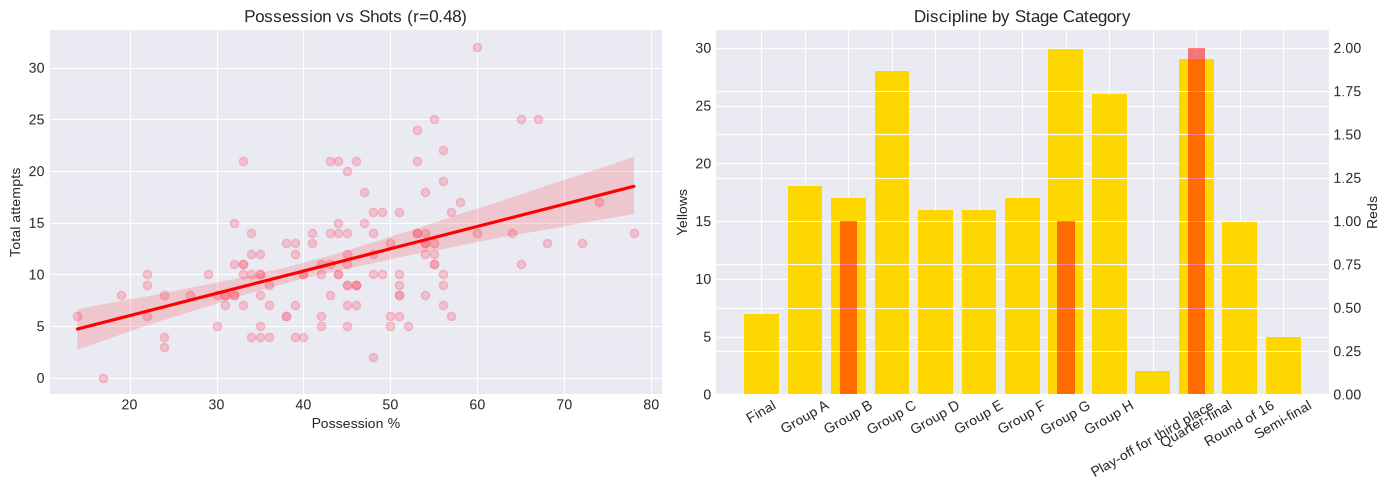

In [10]:
# Does possession buy shots? (64 matches, both sides pooled)
pool = pd.concat([
    pd.DataFrame({'xg_side': 'home', 'poss': d22['possession team1'], 'shots': d22['total attempts team1'],
                  'goals': d22['number of goals team1']}),
    pd.DataFrame({'xg_side': 'away', 'poss': d22['possession team2'], 'shots': d22['total attempts team2'],
                  'goals': d22['number of goals team2']}),
])
r = pool['poss'].corr(pool['shots'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=pool, x='poss', y='shots', ax=axes[0], scatter_kws={'alpha': .35}, line_kws={'color': 'red'})
axes[0].set_title(f'Possession vs Shots (r={r:.2f})')
axes[0].set_xlabel('Possession %'); axes[0].set_ylabel('Total attempts')
cards = d22.groupby('category')[['yellow cards team1', 'yellow cards team2', 'red cards team1', 'red cards team2']].sum()
cards.columns = ['Y1', 'Y2', 'R1', 'R2']
cards['yellows'] = cards.Y1 + cards.Y2
cards['reds'] = cards.R1 + cards.R2
axes[1].bar(cards.index, cards['yellows'], color='gold', label='Yellows')
ax2 = axes[1].twinx()
ax2.bar(cards.index, cards['reds'], color='red', alpha=.5, width=.4, label='Reds')
axes[1].set_title('Discipline by Stage Category')
axes[1].set_ylabel('Yellows'); ax2.set_ylabel('Reds')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 5. North America 2026 (simulated)

In [11]:
# Group standings from simulated results
name_of = dict(zip(teams26['team_id'], teams26['team_name']))
code_of = dict(zip(teams26['team_id'], teams26['fifa_code']))
stage_of = dict(zip(stages26['stage_id'], stages26['stage_name']))

matches26['stage'] = matches26['stage_id'].map(stage_of)
group_games = matches26[matches26['stage_id'] == 1]

standings = []
for tid in teams26['team_id']:
    home = group_games[group_games['home_team_id'] == tid]
    away = group_games[group_games['away_team_id'] == tid]
    gf = int(home['home_score'].sum() + away['away_score'].sum())
    ga = int(home['away_score'].sum() + away['home_score'].sum())
    hw = (home['home_score'] > home['away_score']).sum(); aw = (away['away_score'] > away['home_score']).sum()
    hd = (home['home_score'] == home['away_score']).sum(); ad = (away['away_score'] == away['home_score']).sum()
    standings.append({
        'group': teams26.loc[teams26['team_id'] == tid, 'group_letter'].iloc[0],
        'team': name_of[tid], 'P': len(home) + len(away),
        'W': int(hw + aw), 'D': int(hd + ad), 'L': int(len(home) + len(away) - hw - aw - hd - ad),
        'GF': gf, 'GA': ga, 'GD': gf - ga, 'Pts': int(3 * (hw + aw) + (hd + ad)),
    })
std = pd.DataFrame(standings).sort_values(['group', 'Pts', 'GD'], ascending=[True, False, False])
print(f"Group stage: {len(group_games)} games played")
display(std.groupby('group').head(2).reset_index(drop=True))  # qualifiers

Group stage: 72 games played


,group,team,P,W,D,L,GF,GA,GD,Pts
0,A,Mexico,3,3,0,0,6,0,6,9
1,A,South Africa,3,1,1,1,2,3,-1,4
2,B,Switzerland,3,2,1,0,7,3,4,7
3,B,Canada,3,1,1,1,8,3,5,4
4,C,Brazil,3,2,1,0,7,1,6,7
5,C,Morocco,3,2,1,0,6,3,3,7
6,D,USA,3,2,0,1,8,4,4,6
7,D,Australia,3,1,1,1,2,2,0,4
8,E,Germany,3,2,0,1,10,4,6,6
9,E,Côte d'Ivoire,3,2,0,1,4,2,2,6


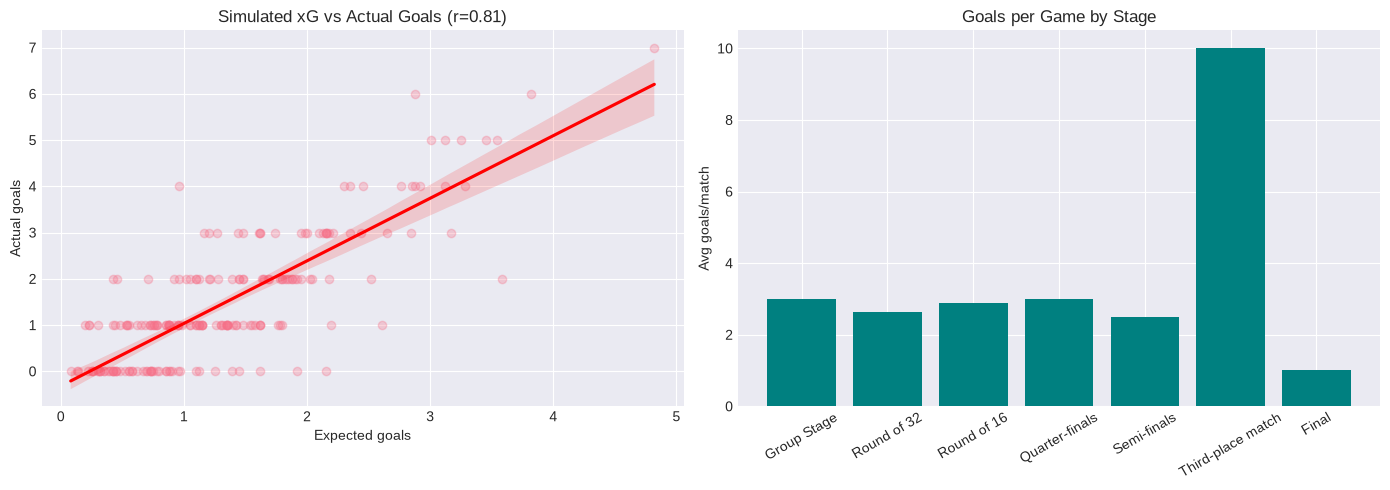

In [12]:
# xG model quality: simulated xG vs actual goals
sides = pd.concat([
    pd.DataFrame({'xg': matches26['home_xg'], 'goals': matches26['home_score']}),
    pd.DataFrame({'xg': matches26['away_xg'], 'goals': matches26['away_score']}),
])
corr = sides['xg'].corr(sides['goals'])

by_stage = matches26.copy()
by_stage['total'] = by_stage['home_score'] + by_stage['away_score']
stage_gpg = by_stage.groupby('stage')['total'].agg(['mean', 'count'])
order = stage_gpg.reindex([stage_of[i] for i in sorted(stage_of)]).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=sides, x='xg', y='goals', ax=axes[0], scatter_kws={'alpha': .3}, line_kws={'color': 'red'})
axes[0].set_title(f'Simulated xG vs Actual Goals (r={corr:.2f})')
axes[0].set_xlabel('Expected goals'); axes[0].set_ylabel('Actual goals')
axes[1].bar(order.index, order['mean'], color='teal')
axes[1].set_title('Goals per Game by Stage')
axes[1].set_ylabel('Avg goals/match')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

In [13]:
# Champion's path through the knockout rounds
final = matches26[matches26['stage'] == 'Final'].iloc[0]
if pd.notna(final['home_penalty_score']) and final['home_penalty_score'] != final['away_penalty_score']:
    champ_id = final['home_team_id'] if final['home_penalty_score'] > final['away_penalty_score'] else final['away_team_id']
else:
    champ_id = final['home_team_id'] if final['home_score'] > final['away_score'] else final['away_team_id']
champ = name_of[champ_id]
print(f'Simulated champion: {champ} ({code_of[champ_id]})\n')

path = matches26[(matches26['home_team_id'] == champ_id) | (matches26['away_team_id'] == champ_id)]
path = path[path['stage_id'] > 1].sort_values('match_id')
for _, r in path.iterrows():
    hs, as_ = int(r['home_score']), int(r['away_score'])
    pen = f" ({int(r['home_penalty_score'])}-{int(r['away_penalty_score'])} pens)" if pd.notna(r['home_penalty_score']) else ''
    print(f"{r['stage']:<20} {name_of[r['home_team_id']]} {hs}-{as_}{pen} {name_of[r['away_team_id']]}")

Simulated champion: Spain (ESP)

Round of 32          Spain 3-0 Austria
Round of 16          Portugal 0-1 Spain
Quarter-finals       Spain 2-1 Belgium
Semi-finals          France 0-2 Spain
Final                Spain 1-0 Argentina


## 6. Players & Referees

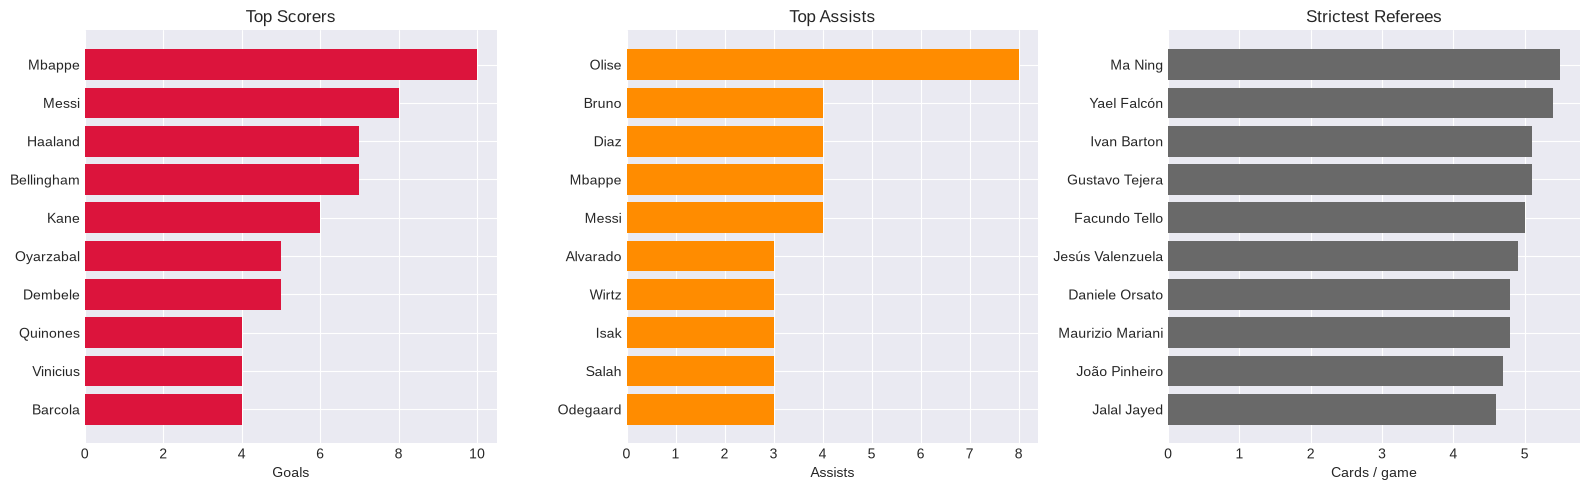

Busiest referees (matches):


,matches
referee_id,
César Arturo Ramos,5
João Pinheiro,5
Maurizio Mariani,5
Daniele Orsato,4
Mustapha Ghorbal,4


In [14]:
# Player leaders (simulated tournament totals) and referee workload
pl = players26.merge(teams26[['team_id', 'team_name']], on='team_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
top_g = pl.nlargest(10, 'goals')
axes[0].barh(top_g['player_name'].str.split().str[-1][::-1], top_g['goals'][::-1], color='crimson')
axes[0].set_title('Top Scorers'); axes[0].set_xlabel('Goals')
top_a = pl.nlargest(10, 'assists')
axes[1].barh(top_a['player_name'].str.split().str[-1][::-1], top_a['assists'][::-1], color='darkorange')
axes[1].set_title('Top Assists'); axes[1].set_xlabel('Assists')
refs = referees26.sort_values('avg_cards_per_game', ascending=False).head(10)
axes[2].barh(refs['name'][::-1], refs['avg_cards_per_game'][::-1], color='dimgray')
axes[2].set_title('Strictest Referees'); axes[2].set_xlabel('Cards / game')
plt.tight_layout(); plt.show()

workload = matches26['referee_id'].value_counts().rename(index=dict(zip(referees26['referee_id'], referees26['name'])))
print('Busiest referees (matches):')
display(workload.head(5).to_frame('matches'))

## 7. ML Baseline: Predicting 2026 Match Results

Logistic regression on pre-match features only (Elo, FIFA rank, squad value/age/caps,
rest days, previous form) to predict H/D/A. Compares against the majority-class baseline.

Majority-class baseline: 46.2%
Logistic regression:     73.1%

              precision    recall  f1-score   support

           A       0.88      0.88      0.88         8
           D       0.67      0.33      0.44         6
           H       0.67      0.83      0.74        12

    accuracy                           0.73        26
   macro avg       0.74      0.68      0.69        26
weighted avg       0.73      0.73      0.71        26



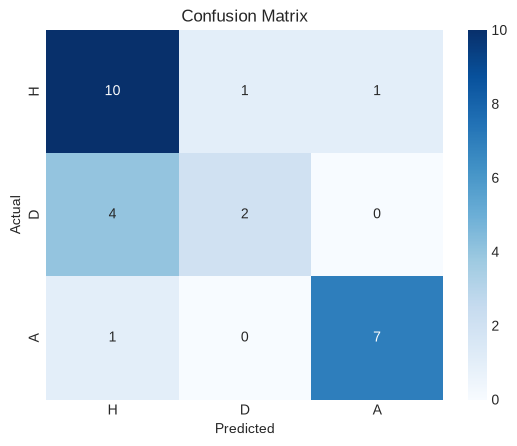

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_raw = pd.read_csv(DATA / 'match_prediction_features_X.csv')
y = pd.read_csv(DATA / 'match_prediction_targets_y.csv')
df = X_raw.merge(y[['match_id', 'match_result']], on='match_id')

# Engineered differences (home minus away perspective)
feats = pd.DataFrame({
    'elo_diff': df['home_elo'] - df['away_elo'],
    'rank_diff': df['away_fifa_rank'] - df['home_fifa_rank'],   # lower rank number = better
    'value_diff': np.log(df['home_squad_total_value_eur']) - np.log(df['away_squad_total_value_eur']),
    'caps_diff': df['home_squad_total_caps'] - df['away_squad_total_caps'],
    'age_diff': df['home_squad_avg_age'] - df['away_squad_avg_age'],
    'rest_diff': df['home_rest_days'] - df['away_rest_days'],
    'host_adv': df['home_is_host'].astype(int) - df['away_is_host'].astype(int),
    'xg_form_diff': df['home_prev_avg_xg_scored'] - df['away_prev_avg_xg_scored'],
    'goals_form_diff': df['home_prev_avg_goals_scored'] - df['away_prev_avg_goals_scored'],
    'knockout': df['is_knockout'].astype(int),
})
target = df['match_result']

X_tr, X_te, y_tr, y_te = train_test_split(feats, target, test_size=.25, stratify=target, random_state=42)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model.fit(X_tr, y_tr)
pred = model.predict(X_te)

baseline = max(y_te.value_counts()) / len(y_te)
acc = accuracy_score(y_te, pred)
print(f'Majority-class baseline: {baseline:.1%}')
print(f'Logistic regression:     {acc:.1%}\n')
print(classification_report(y_te, pred))

cm = confusion_matrix(y_te, pred, labels=['H', 'D', 'A'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['H', 'D', 'A'], yticklabels=['H', 'D', 'A'])
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

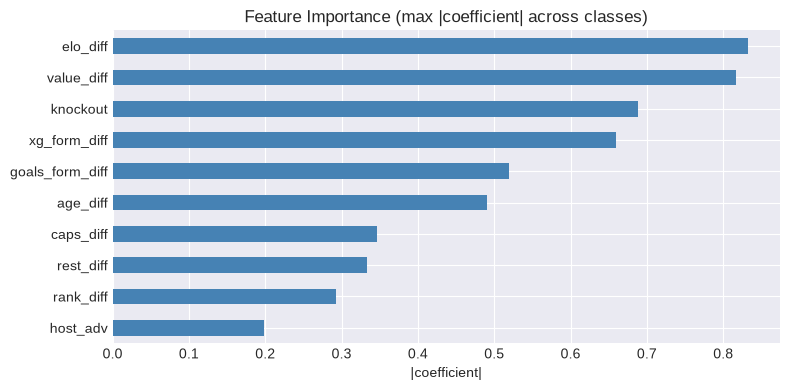

In [16]:
# Which engineered features matter most?
logreg = model.named_steps['logisticregression']
coef = pd.DataFrame(logreg.coef_, columns=feats.columns, index=['H', 'D', 'A'])
importance = coef.abs().max().sort_values(ascending=True)
importance.plot(kind='barh', figsize=(8, 4), color='steelblue', legend=False)
plt.title('Feature Importance (max |coefficient| across classes)')
plt.xlabel('|coefficient|')
plt.tight_layout(); plt.show()